# Imports and reads

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from utils.data_loader import load_parquet, find_repo_root
from pathlib import Path

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay', 'F10.7 (LASP)', 'Kp (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 4)
                 time  orbital_decay  F10.7 (LASP)  Kp (LASP)
0 2023-01-01 00:00:00        16.6730         153.0      2.333
1 2023-01-01 00:00:20        16.6730         153.0      2.333
2 2023-01-01 00:00:40        16.6735         153.0      2.333
3 2023-01-01 00:01:00        16.6740         153.0      2.333
4 2023-01-01 00:01:20        16.6740         153.0      2.333


In [2]:
df = GFOC_data.copy()
time = df['time'].values

# make 'time' the index
df.set_index('time', inplace=True)
df.index = pd.to_datetime(df.index)
dt_seconds = (df.index[1] - df.index[0]).total_seconds()

# Import Subsets

In [17]:
Kp_DIR = find_repo_root() / Path("Analysis/Subsets/")
Kp_names = ['Kp', 'eflag_meanstd'] #, 'merged', 'eflag_meanstd', eflag', 'meanstd'

for name in Kp_names:
    filename = 'subsets_' + name + '.csv'
    subset = pd.read_csv(Kp_DIR / filename)
    print(f"\nSubsets from {name}:")
    print("No of subsets:", len(subset))


Subsets from Kp:
No of subsets: 50

Subsets from eflag_meanstd:
No of subsets: 58


add to df

In [18]:
for name in Kp_names:
    filename = 'subsets_' + name + '.csv'
    subset = pd.read_csv(Kp_DIR / filename)
    df[name] = None

    # mo flags
    interval_starts = pd.to_datetime(subset['start']).dropna()

    interval_ends = pd.to_datetime(subset['end']).dropna()

    intervals = list(zip(interval_starts, interval_ends))
    i = 1
    for start, end in intervals:
        df.loc[(df.index >= start) & (df.index <= end), name] = i
        i += 1

In [19]:
# print percentage of data points
print("\nPercentage of data points in subsets compared to total data points:")
for name in Kp_names:
    subset_counts = np.sum(df[name].value_counts(dropna=True))
    total_counts = len(df)
    print(f"\n{name}: {subset_counts / total_counts * 100:.1f}%")


Percentage of data points in subsets compared to total data points:

Kp: 18.6%

eflag_meanstd: 50.1%


# Plot

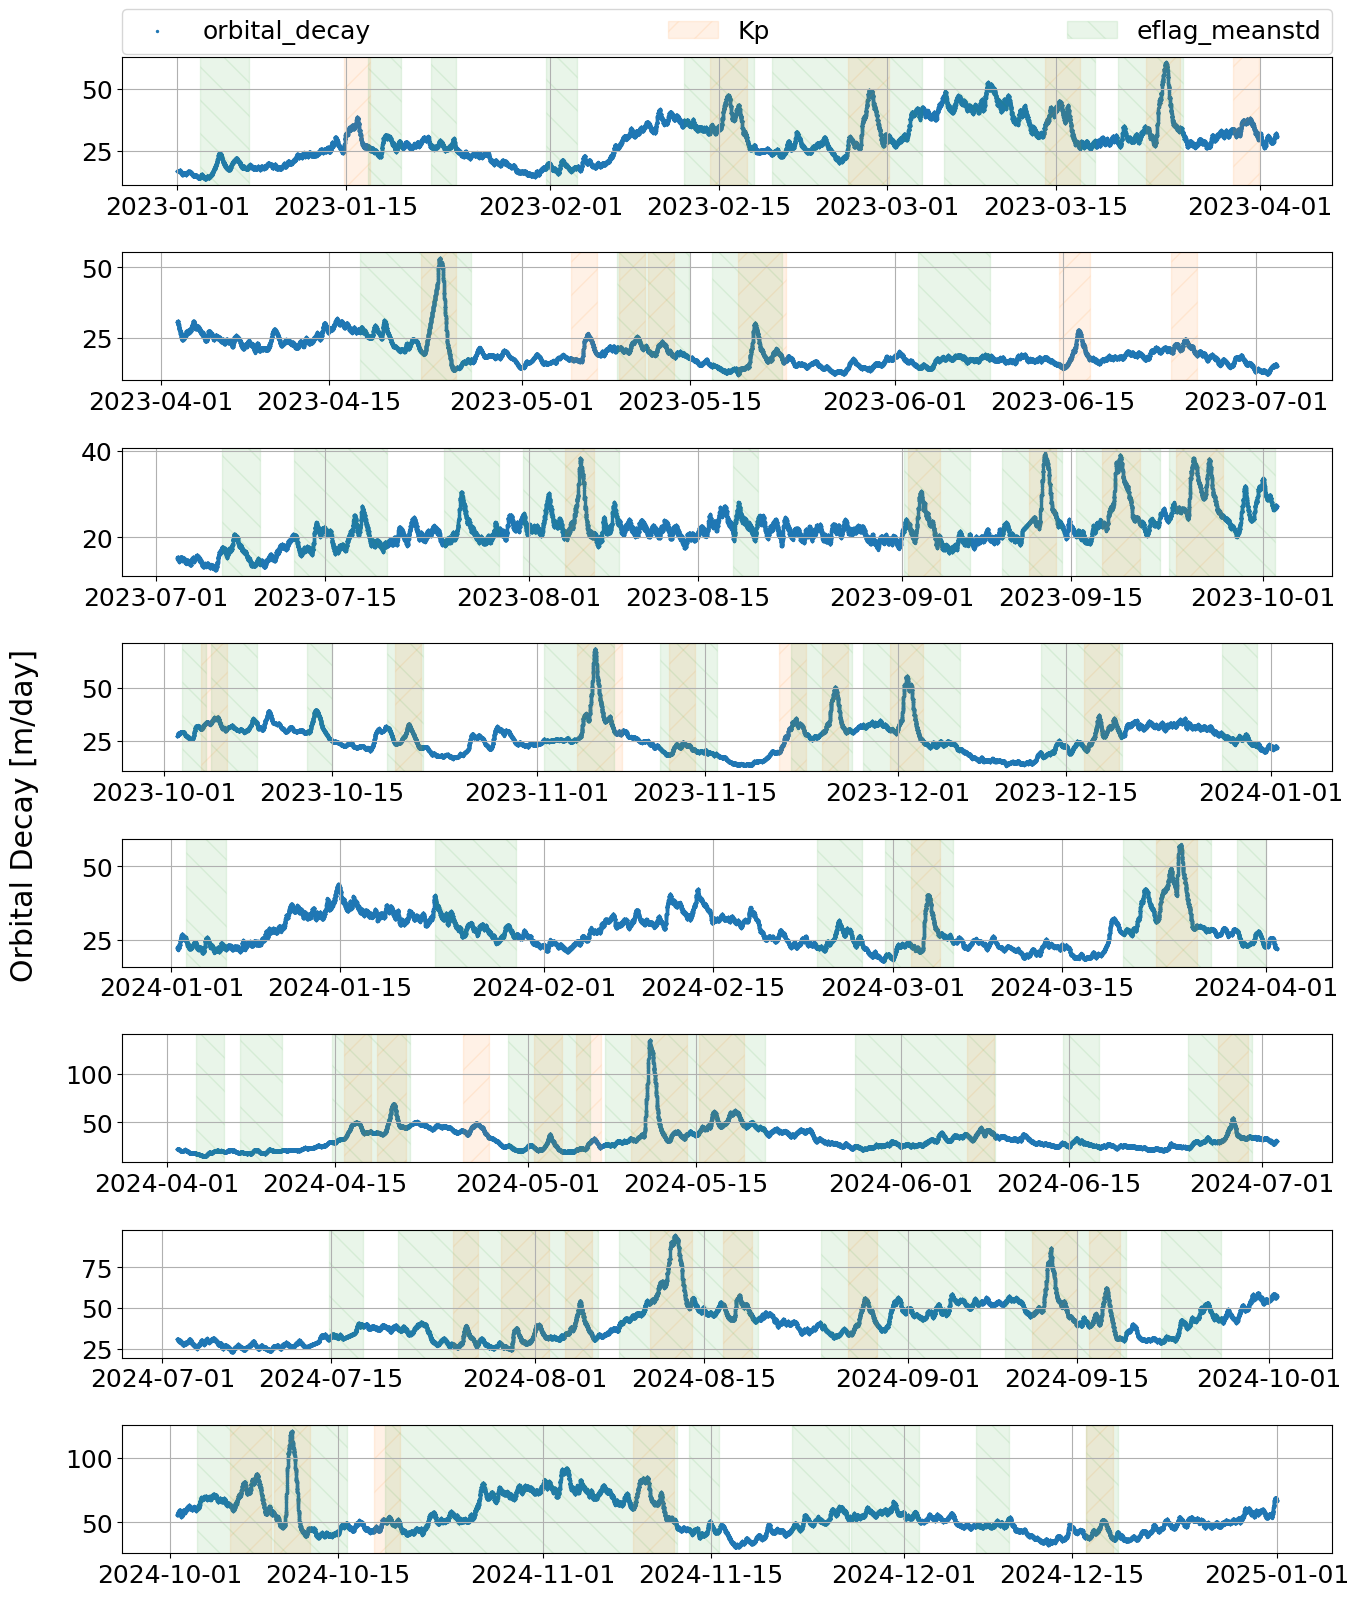

In [20]:
N = 8  # number of subplots

# Downsampled view
ysub = df.iloc[::8]

# create color map once
cmap = plt.get_cmap("tab10")  # good categorical colormap
name_to_color = {
    name: cmap((i+1) % cmap.N)
    for i, name in enumerate(sorted(Kp_names))
}
hatch_styles = ['/', '\\', '-', 'o', '.', '*']
name_to_hatch = {
    name: hatch_styles[i % len(hatch_styles)]
    for i, name in enumerate(sorted(Kp_names))
}

# split indices into N nearly equal chunks
splits = np.array_split(ysub.index, N)
plt.close('all')
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(N, 1, figsize=(14, 2*N), sharey=False)

for ax, idx_chunk in zip(axes, splits):

    # slice the dataframe for this subplot
    chunk = ysub.loc[idx_chunk]

    ax.scatter(
        chunk.index,
        chunk['orbital_decay'],
        s=2,
        label='orbital_decay'
    )

    # ax2 = ax.twinx()
    # ax2.scatter(
    #     chunk.index,
    #     chunk['Kp (LASP)'],
    #     s=1,
    #     color='black',
    #     label='Kp (LASP)'
    # )

    for name in Kp_names:
        flagged = chunk[chunk[name] == 1]
        event_ids = chunk[name].dropna().unique()
        for event_id in event_ids:
            event_data = chunk[chunk[name] == event_id]
            start_time = event_data.index[0]
            end_time = event_data.index[-1]
            ax.axvspan(start_time, end_time, color=name_to_color[name], hatch=name_to_hatch[name], alpha=0.1, label = f'{name}')

    ax.grid(True)
    # ax.set_ylabel("orbital_decay [m/day]")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(),
    bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
    ncols=5, mode="expand", borderaxespad=0.)
fig.supylabel("Orbital Decay [m/day]")
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()

Plot only specific time range for detailed analysis

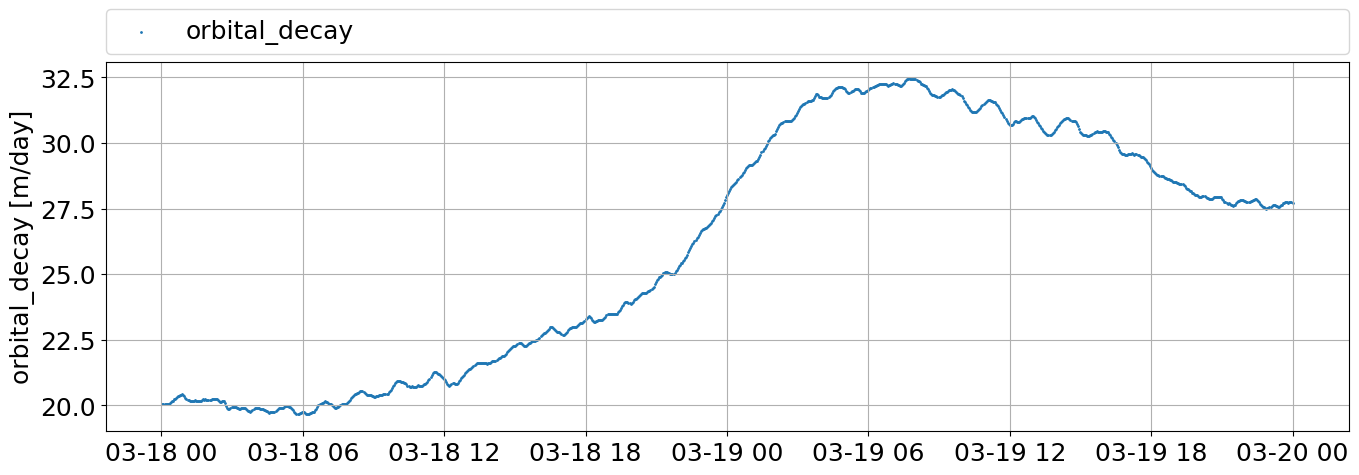

In [21]:
start_time = '2024-03-18 00:00:00'
end_time = '2024-03-20 00:00:00'

# Downsampled view
ysub = df.iloc[::8]

# filter ysub for the specified time range
chunk = ysub.loc[start_time:end_time]

# create color map once
cmap = plt.get_cmap("tab10")  # good categorical colormap
name_to_color = {
    name: cmap((i+1) % cmap.N)
    for i, name in enumerate(sorted(Kp_names))
}
plt.close('all')
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(
    chunk.index,
    chunk['orbital_decay'],
    s=1,
    label='orbital_decay'
)

# ax2 = ax.twinx()
# ax2.scatter(
#     chunk.index,
#     chunk['Kp (LASP)'],
#     s=1,
#     color='black',
#     label='Kp (LASP)'
# )

for name in Kp_names:
    flagged = chunk[chunk[name] == 1]
    event_ids = chunk[name].dropna().unique()
    for event_id in event_ids:
        event_data = chunk[chunk[name] == event_id]
        start_time = event_data.index[0]
        end_time = event_data.index[-1]
        ax.axvspan(start_time, end_time, color=name_to_color[name], alpha=0.1, label = f'{name}')

ax.grid(True)
ax.set_ylabel("orbital_decay [m/day]")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
    bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
    ncols=5, mode="expand", borderaxespad=0.)
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()